# Ensemble Learning — Hands-On Notebook

### Bagging · Boosting · Stacking & Voting · Hyperparameter Tuning · Model Comparison

**Course:** Data Science & AI/ML Professional  |  **Instructor:** Netra Neupane

---
One dataset, every ensemble family — so every comparison in this notebook is apples to apples.
We use the **Breast Cancer Wisconsin** dataset (built into scikit-learn): 30 numeric features,
binary target (malignant / benign). It's realistic enough to show real differences between models,
but small enough to run instantly on a laptop.

**What you'll do**
1. Load data & set a baseline (a single Decision Tree)
2. Bagging & Random Forest — cut variance
3. AdaBoost — boost by re-weighting points
4. Gradient Boosting — boost by fitting residuals (+ overfitting demo)
5. Voting & Stacking — combine different model types
6. Hyperparameter tuning — Grid vs Randomized search
7. Fair model comparison — cross-validated boxplot
8. Exercises

## 0. Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                      StratifiedKFold, GridSearchCV, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, VotingClassifier, StackingClassifier)
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
plt.rcParams['figure.figsize'] = (7, 5)
print('Setup complete.')

Setup complete.


## 1. Load data & set a baseline

**Breast Cancer Wisconsin:** 569 samples, 30 features (computed from cell nuclei images),
target: 0 = malignant, 1 = benign.

In [4]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
print('Shape:', X.shape)
print('Class balance:\n', y.value_counts())
X.head()

Shape: (569, 30)
Class balance:
 target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]}   Test: {X_test.shape[0]}')

Train: 426   Test: 143


### Baseline: a single Decision Tree
Every ensemble in this notebook must beat this to justify its extra complexity.

In [6]:
baseline = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
# baseline.fit(X_train, y_train)
baseline_scores = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='accuracy')
print(f'Single tree   CV accuracy: {baseline_scores.mean():.3f}  (+/- {baseline_scores.std():.3f})')

Single tree   CV accuracy: 0.927  (+/- 0.022)


## 2. Bagging & Random Forest — cutting variance

**Bagging**: train many copies of a model on random bootstrap samples, then vote.
**Random Forest** = bagging + random feature subsets per split (extra diversity).

In [7]:
# Plain bagging with decision trees as the base estimator
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=200,
    oob_score=True,
    random_state=RANDOM_STATE,
    n_jobs=-1)
bagging.fit(X_train, y_train)
print('Bagging  OOB score:', round(bagging.oob_score_, 3))
print('Bagging  CV accuracy:', round(cross_val_score(bagging, X_train, y_train, cv=cv).mean(), 3))

Bagging  OOB score: 0.955
Bagging  CV accuracy: 0.955


In [8]:
# Random Forest — bagging + feature randomness
rf = RandomForestClassifier(
    n_estimators=200, max_features='sqrt', oob_score=True,
    random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
print('Random Forest  OOB score:', round(rf.oob_score_, 3))
print('Random Forest  CV accuracy:', round(cross_val_score(rf, X_train, y_train, cv=cv).mean(), 3))

Random Forest  OOB score: 0.962
Random Forest  CV accuracy: 0.965


### Variance check: does bagging actually reduce variance?
We compare how much a single tree's accuracy swings across different CV folds vs. the forest's.

In [9]:
tree_cv = cross_val_score(DecisionTreeClassifier(random_state=RANDOM_STATE), X_train, y_train, cv=cv)
rf_cv   = cross_val_score(rf, X_train, y_train, cv=cv)

print(f'Single tree    fold scores: {np.round(tree_cv, 3)}  ->  std={tree_cv.std():.4f}')
print(f'Random Forest  fold scores: {np.round(rf_cv, 3)}  ->  std={rf_cv.std():.4f}')
print('\nLower std = less variance = more stable predictions across different data samples.')

Single tree    fold scores: [0.942 0.906 0.929 0.906 0.941]  ->  std=0.0161
Random Forest  fold scores: [0.953 0.988 0.941 0.953 0.988]  ->  std=0.0196

Lower std = less variance = more stable predictions across different data samples.


## 3. AdaBoost — boosting by re-weighting points

AdaBoost trains a sequence of **weak learners** (shallow trees, often depth-1 'stumps').
After each round, misclassified points get **heavier weights** so the next learner focuses on them.

In [10]:
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2, random_state=RANDOM_STATE), # weak lerner
    n_estimators=200, # train 100 weak lerner sequentially
    learning_rate=0.1,
    random_state=RANDOM_STATE)
ada.fit(X_train, y_train)
print('AdaBoost  CV accuracy:', round(cross_val_score(ada, X_train, y_train, cv=cv).mean(), 3))

AdaBoost  CV accuracy: 0.96


### Watching accuracy build up, round by round
`staged_predict` lets us see the ensemble's prediction after each additional stump —
this is the clearest way to *see* boosting happen.

/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


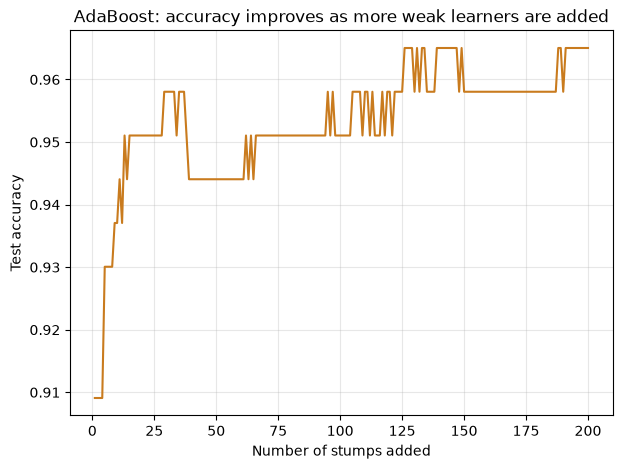

Accuracy after 1 stump: 0.909   after 200 stumps: 0.965


In [11]:
staged_acc = [accuracy_score(y_test, pred) for pred in ada.staged_predict(X_test)]

plt.figure()
plt.plot(range(1, len(staged_acc) + 1), staged_acc, color='#C97B1E')
plt.xlabel('Number of stumps added'); plt.ylabel('Test accuracy')
plt.title('AdaBoost: accuracy improves as more weak learners are added')
plt.grid(alpha=0.3); plt.show()
print(f'Accuracy after 1 stump: {staged_acc[0]:.3f}   after {len(staged_acc)} stumps: {staged_acc[-1]:.3f}')

## 4. Gradient Boosting — boosting by fitting residuals

Instead of re-weighting points, Gradient Boosting trains each new tree to predict the
**errors (residuals)** left by everything built so far, and adds a small, scaled correction
(`learning_rate`).

In [12]:
gbm = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1, max_depth=3,
    subsample=0.6, random_state=RANDOM_STATE)
gbm.fit(X_train, y_train)
print('Gradient Boosting  CV accuracy:', round(cross_val_score(gbm, X_train, y_train, cv=cv).mean(), 3))

Gradient Boosting  CV accuracy: 0.981


### Gradient Boosting CAN overfit — unlike Random Forest
We sweep `n_estimators` and watch train vs. test accuracy. Notice train accuracy keeps
climbing toward 1.0 while test accuracy plateaus (and can even dip) — the overfitting signature
that Random Forest doesn't show.

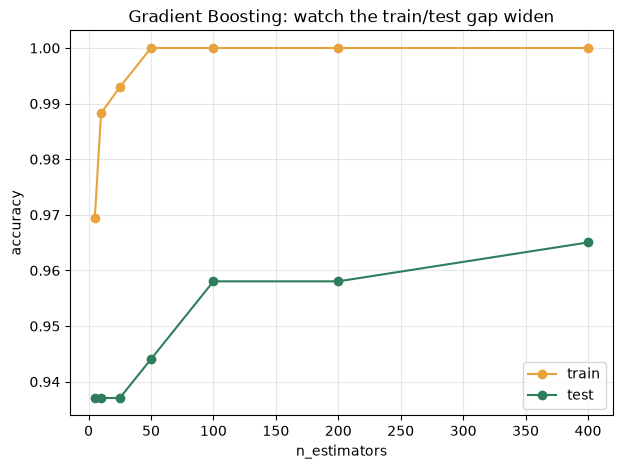

In [13]:
n_range = [5, 10, 25, 50, 100, 200, 400]
train_accs, test_accs = [], []
for n in n_range:
    m = GradientBoostingClassifier(n_estimators=n, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE)
    m.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, m.predict(X_train)))
    test_accs.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure()
plt.plot(n_range, train_accs, 'o-', label='train', color='#E8A33D')
plt.plot(n_range, test_accs,  'o-', label='test',  color='#2E7D5B')
plt.xlabel('n_estimators'); plt.ylabel('accuracy')
plt.title('Gradient Boosting: watch the train/test gap widen')
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Early stopping — the practical fix
`n_iter_no_change` stops adding trees once the validation score stops improving,
so you don't have to guess `n_estimators` by hand.

In [14]:
gbm_early = GradientBoostingClassifier(
    n_estimators=1000, learning_rate=0.1, max_depth=3,
    validation_fraction=0.15, n_iter_no_change=10, tol=1e-4,
    random_state=RANDOM_STATE)
gbm_early.fit(X_train, y_train)
print(f'Stopped after {gbm_early.n_estimators_} trees (asked for up to 1000).')
print('Test accuracy:', round(accuracy_score(y_test, gbm_early.predict(X_test)), 3))

Stopped after 110 trees (asked for up to 1000).
Test accuracy: 0.951


*(Optional, if installed)* **XGBoost** — the industrial version of the same idea, with speed
and regularization built in. Uncomment to try it.

In [15]:
# import xgboost as xgb
# xgb_clf = xgb.XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=3,
#                              subsample=0.8, colsample_bytree=0.8,
#                              eval_metric='logloss', random_state=RANDOM_STATE)
# xgb_clf.fit(X_train, y_train)
# print('XGBoost test accuracy:', accuracy_score(y_test, xgb_clf.predict(X_test)))

## 5. Voting & Stacking — combining different model types

Bagging and boosting each combine many copies of the **same** algorithm.
Voting and stacking combine **different** algorithms.

In [16]:
# Base models — deliberately different in how they think
clf_rf  = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
clf_svm = make_pipeline(StandardScaler(), SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE))
clf_lr  = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, random_state=RANDOM_STATE))

for name, clf in [('Random Forest', clf_rf), ('SVM', clf_svm), ('Logistic Regression', clf_lr)]:
    score = cross_val_score(clf, X_train, y_train, cv=cv).mean()
    print(f'{name:22s} CV accuracy: {score:.3f}')

Random Forest          CV accuracy: 0.965
SVM                    CV accuracy: 0.967
Logistic Regression    CV accuracy: 0.979


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

### Hard vs Soft voting

In [17]:
voting_hard = VotingClassifier(
    estimators=[('rf', clf_rf), ('svm', clf_svm), ('lr', clf_lr)], voting='hard')
voting_soft = VotingClassifier(
    estimators=[('rf', clf_rf), ('svm', clf_svm), ('lr', clf_lr)], voting='soft')

print('Hard voting  CV accuracy:', round(cross_val_score(voting_hard, X_train, y_train, cv=cv).mean(), 3))
print('Soft voting  CV accuracy:', round(cross_val_score(voting_soft, X_train, y_train, cv=cv).mean(), 3))

/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

Hard voting  CV accuracy: 0.977


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

Soft voting  CV accuracy: 0.981


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


### Stacking — let a meta-model learn how to combine
`StackingClassifier` automatically trains the meta-model on **out-of-fold** predictions,
so there's no leakage from base models to the meta-model.

In [18]:
stack = StackingClassifier(
    estimators=[('rf', clf_rf), ('svm', clf_svm), ('lr', clf_lr)],
    final_estimator=LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    cv=5)
stack_score = cross_val_score(stack, X_train, y_train, cv=cv).mean()
print('Stacking  CV accuracy:', round(stack_score, 3))

/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

Stacking  CV accuracy: 0.979


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

## 6. Hyperparameter tuning — Grid vs Randomized search

We tune a Gradient Boosting model two ways and compare the search cost.

In [19]:
import time

param_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth':     [2, 3, 4],
}

gbm_for_search = GradientBoostingClassifier(random_state=RANDOM_STATE)

t0 = time.time()
grid = GridSearchCV(gbm_for_search, param_grid, cv=3, n_jobs=-1)
grid.fit(X_train, y_train)
grid_time = time.time() - t0
print(f'GridSearchCV     : {len(grid.cv_results_["params"])} combos in {grid_time:.1f}s')
print('Best params:', grid.best_params_, '  best CV score:', round(grid.best_score_, 3))

GridSearchCV     : 27 combos in 10.4s
Best params: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 300}   best CV score: 0.967


In [20]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators':  randint(50, 400),
    'learning_rate': uniform(0.01, 0.29),   # 0.01 to 0.30
    'max_depth':     randint(2, 6),
}

t0 = time.time()
rand_search = RandomizedSearchCV(gbm_for_search, param_dist, n_iter=20, cv=3,
                                  random_state=RANDOM_STATE, n_jobs=-1)
rand_search.fit(X_train, y_train)
rand_time = time.time() - t0
print(f'RandomizedSearchCV: {20} combos in {rand_time:.1f}s')
print('Best params:', rand_search.best_params_, '  best CV score:', round(rand_search.best_score_, 3))
print(f'\nGrid explored {len(grid.cv_results_["params"])} combos; Random explored 20 — compare the scores above.')

RandomizedSearchCV: 20 combos in 8.8s
Best params: {'learning_rate': np.float64(0.22227824312530747), 'max_depth': 2, 'n_estimators': 70}   best CV score: 0.962

Grid explored 27 combos; Random explored 20 — compare the scores above.


## 7. Fair model comparison

Same CV folds, same data, for every model — then look at the **spread**, not just the mean.

In [21]:
models = {
    'Decision Tree':      DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    'Bagging':            bagging,
    'Random Forest':      rf,
    'AdaBoost':           ada,
    'Gradient Boosting':  gbm,
    'Voting (soft)':      voting_soft,
    'Stacking':           stack,
    'Tuned GBM':          rand_search.best_estimator_,
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    results[name] = scores
    print(f'{name:20s} mean={scores.mean():.3f}  std={scores.std():.3f}')

Decision Tree        mean=0.927  std=0.019
Bagging              mean=0.955  std=0.019
Random Forest        mean=0.965  std=0.020
AdaBoost             mean=0.960  std=0.017
Gradient Boosting    mean=0.981  std=0.006


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

Voting (soft)        mean=0.981  std=0.006


/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/likhita/projects/venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was dep

Stacking             mean=0.979  std=0.005
Tuned GBM            mean=0.955  std=0.025


In [22]:
plt.figure(figsize=(10, 5))
plt.boxplot(results.values(), labels=results.keys())
plt.xticks(rotation=30, ha='right')
plt.ylabel('CV accuracy')
plt.title('Model comparison — spread matters as much as the mean')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

TypeError: boxplot() got an unexpected keyword argument 'labels'

<Figure size 1000x500 with 0 Axes>

### The final exam: touch the test set once
Pick your winning model from the CV comparison above, then evaluate it on the untouched test set.

In [ ]:
best_name = max(results, key=lambda k: results[k].mean())
best_model = models[best_name]
best_model.fit(X_train, y_train)

print(f'Best model by CV: {best_name}')
print('Test accuracy:', round(accuracy_score(y_test, best_model.predict(X_test)), 3))
print('Test F1 score :', round(f1_score(y_test, best_model.predict(X_test)), 3))
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=data.target_names))

## 8. Your turn — exercises

1. **Feature importance.** Plot feature importances from the Random Forest and the Gradient
   Boosting model. Do they agree on the top features?
2. **Learning rate vs n_estimators.** Halve `learning_rate` on the Gradient Boosting model
   and roughly double `n_estimators`. Does accuracy hold steady? What about training time?
3. **Break stacking.** Refit `StackingClassifier` with `cv=2` instead of `cv=5`. Does
   performance change? Why might too few folds hurt the meta-model?
4. **AdaBoost depth.** Change the AdaBoost base estimator from `max_depth=1` to `max_depth=3`.
   Does it still behave like 'boosting of weak learners', or does it start overfitting?
5. **Try XGBoost/LightGBM** if installed, and add it to the final comparison boxplot.
6. **Imbalance stress-test.** Drop 90% of the malignant cases to make the data imbalanced,
   then re-run the comparison using `f1` or `roc_auc` instead of `accuracy` as the CV scoring.

*Tip:* keep `random_state=42` everywhere so your results are reproducible and comparable
to your classmates'.

In [ ]:
# Scratch space for your experiments
